# nb_01 — Prepare a DP2 subset to play with

Goal (see `docs/SPEC_V01.md`, rough plan step 1): visualize the DP2 `diaObject` footprint
(coverage and cadence), pick a handful of fields by eye from those maps, keep only objects
with more than 10 `diaSources` in each, and save that small subset to a shared location so
workshop participants can work with it directly instead of touching the full ~5 TB collection.

**Environment note (RSP notebook aspect):** this repo's `pyproject.toml` is pinned to Python
3.14 to mirror a local conda env, but the RSP kernel runs Python 3.13.9 with `lsdb`/`hats`
already provided by the stack. We do **not** `pip install .` here — we only need the
`datapaths` package on top of the stack, installed directly:

```bash
pip install --user "datapaths[tabular] @ git+https://github.com/ShrRa/datapaths.git@main"
```

`datapaths` resolves two config files under `configs/`: the committed
`artifacts_registry.yaml`, and a machine-local `roots.local.yaml` (gitignored) that must exist
on whatever machine runs this notebook. On this RSP session it maps:

- `dp2_raw` → `/rubin/lsdb_data/dp2` (the full DP2 collections, read-only)
- `dp2_filtered` → `/deleted-sundays/shrra-ung/dp2` (an already `nDiaSources > 10` filtered
  copy of the full `diaObject` collection, ~300 GB, produced separately — see
  `~/WORK/dp2_diaObj_download.py`)
- `dp2_subset` → `~/share/trieste` (small, shareable subset — this notebook's output)
- `misc` → `~/DATA/DP2` (personal scratch)

If you're running this on a different machine, create your own `configs/roots.local.yaml`
with these four keys pointing at wherever the data actually lives there.

In [14]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hpgeom
import pyarrow.parquet as pq
from astropy.coordinates import SkyCoord
import astropy.units as u

import lsdb
from hats.inspection.visualize_catalog import plot_healpix_map

try:
    from datapaths import Datapaths
except ModuleNotFoundError:
    import sys
    print("datapaths not found — installing it into the user site-packages...")
    !{sys.executable} -m pip install --user --quiet "datapaths[tabular] @ git+https://github.com/ShrRa/datapaths.git@main"
    from datapaths import Datapaths

In [19]:
dp = Datapaths()
dp.roots

{'dp2_raw': PosixPath('/rubin/lsdb_data/dp2'),
 'dp2_filtered': PosixPath('/deleted-sundays/shrra-ung/dp2'),
 'dp2_hq': PosixPath('/deleted-sundays/shrra-ung/dp2_hq'),
 'dp2_subset': PosixPath('/home/shrra-ung/share/trieste'),
 'misc': PosixPath('/home/shrra-ung/DATA/DP2')}

## 1. Open the raw `diaObject` collection

`lsdb.open_catalog` on a HATS *collection* directory opens its main catalog and wires up the
default margin cache. By default it loads only the columns listed as `hats_cols_default` in
the catalog's properties file — for `dia_object_lc` that's `ra`, `dec`, `tract`,
`diaObjectId`, `nDiaSources`, and the two nested light-curve columns `diaSource` and
`diaObjectForcedSource` (each a struct-of-lists, one entry per epoch).

There are also ~190 flat per-band summary columns on disk (`u_psfFluxMean`,
`g_scienceFluxMean`, min/max, etc.) that are *not* loaded unless requested via
`columns=[...]` — worth remembering for nb_02's histogram work, since those summary stats
might be more informative than raw diff fluxes for some of the questions there.

In [10]:
dia_object_cat = lsdb.open_catalog(dp["dp2_raw"] / "dia_object_collection")

print(type(dia_object_cat))
print("npartitions:", dia_object_cat.npartitions)
print("default columns:", list(dia_object_cat.columns))

<class 'lsdb.catalog.catalog.Catalog'>
npartitions: 8393
default columns: ['dec', 'diaObjectId', 'nDiaSources', 'ra', 'tract', 'diaObjectForcedSource', 'diaSource']


## 2. Visualize coverage and cadence across the whole footprint

`lsdb`'s built-in `catalog.plot_pixels()` gives a coverage map for free — it colors each
HEALPix tile by its partition order, which HATS picks adaptively so that denser sky (more
objects) gets split into finer tiles. That's our "population" map.

For a "cadence/depth" map, the natural move would be the survey property (`healsparse`) maps
from the `203_Maps` tutorial — but those go through `lsst.daf.butler`, which isn't installed
in this kernel (only in the separate "LSST" JupyterLab kernel we're not running). Instead we
build our own, Butler-free proxy from `/rubin/lsdb_data/dp2/public-files/visit_detector.parquet`
(per-visit, per-detector metadata — no Butler needed): r-band exposures are a fixed ~30s, so
**the number of r-band visits covering a spot on the sky is a direct stand-in for coadd
depth there**. We bin visit centers into the same HEALPix order as the map below and count
distinct visits per pixel.

Both maps use the same Mollweide (`MOL`) projection, so they're directly comparable side by
side — unlike the tutorial's `skyproj` maps, which default to a different one.

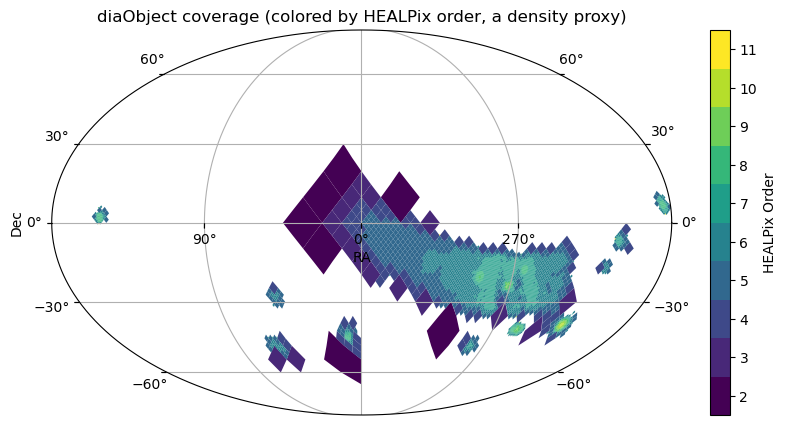

In [11]:
fig, ax = dia_object_cat.plot_pixels(
    plot_title="diaObject coverage (colored by HEALPix order, a density proxy)"
)

30339 order-7 pixels have r-band coverage


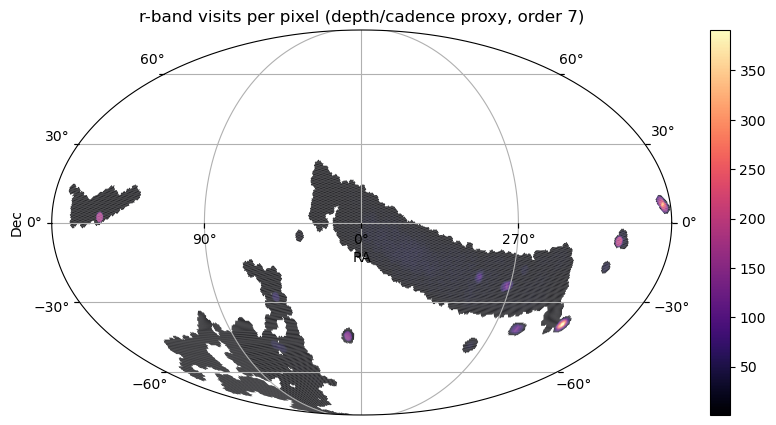

In [12]:
VISIT_MAP_ORDER = 7  # same order used for the field lookups below

visit_cols = ["visitId", "band", "ra", "dec"]
visits = pd.read_parquet(dp["dp2_raw"] / "public-files" / "visit_detector.parquet", columns=visit_cols)
r_visits = visits[visits["band"] == "r"].dropna(subset=["ra", "dec"])

nside = 2 ** VISIT_MAP_ORDER
r_pixel = hpgeom.angle_to_pixel(nside, r_visits["ra"].to_numpy(), r_visits["dec"].to_numpy(), nest=True)
visits_per_pixel = r_visits.assign(pixel=r_pixel).groupby("pixel")["visitId"].nunique()

print(f"{len(visits_per_pixel)} order-{VISIT_MAP_ORDER} pixels have r-band coverage")

fig, ax = plot_healpix_map(
    visits_per_pixel.to_numpy(),
    ipix=visits_per_pixel.index.to_numpy(),
    # a scalar `depth` triggers a panic in this cdshealpix build; an array works around it
    depth=np.full(len(visits_per_pixel), VISIT_MAP_ORDER),
    projection="MOL",
    cmap="magma",
    title="r-band visits per pixel (depth/cadence proxy, order 7)",
)

## 3. Pick your own fields

This is the point of the two maps above: eyeball them, note the (ra, dec) of whatever spots
look interesting, and list them below — nothing downstream depends on the coordinates being
"correct" in any sense, only on the field existing in the coverage map.

The 5 below were picked by eye off the depth map, without cross-checking what's officially
there — they're just coordinates, not claimed field identities. A quick sanity check (nearest
existing partition + `nDiaSources > 10` filter) beforehand showed 4 of them land on
reasonably well-observed sky (hundreds to thousands of survivors); `field_4` is deliberately
kept even though it's thin (31 objects at the nearest partition) — a sparse field is a useful
contrast case, not a mistake to avoid.

In [6]:
FIELDS = [
    ("field_1", 5, -2),
    ("field_2", 320, -16),
    ("field_3", 255, -30),
    ("field_4", 235, -33),  # deliberately sparse, kept as a contrast case
    ("field_5", 12, -45),
]
RADIUS_ARCSEC = 0.3 * 3600  # 0.3 deg; see timing note in section 4

fields_df = pd.DataFrame(FIELDS, columns=["name", "ra", "dec"])
field_coords = SkyCoord(ra=fields_df["ra"].to_numpy() * u.deg, dec=fields_df["dec"].to_numpy() * u.deg)
fields_df["gal_b"] = field_coords.galactic.b.deg
fields_df

,name,ra,dec,gal_b
0,field_1,5,-2,-63.767066
1,field_2,320,-16,-39.957556
2,field_3,255,-30,7.595828
3,field_4,235,-33,17.765093
4,field_5,12,-45,-72.115038


## 4. Filter each field to `nDiaSources > 10` and combine into one subset

`cone_search` (not `pixel_search`) here, since we want an actual circular aperture around
each arbitrary coordinate, not whatever HEALPix tile happens to contain it. We run each
field's `cone_search` + filter + `compute()` separately, `pd.concat` the small resulting
pandas tables, then hand the combined table to `lsdb.from_dataframe` (meant for exactly this:
small, in-memory data — safe well under its "<1M rows / <1GB" guidance here) to get back a
proper `lsdb.Catalog` to write.

**Performance note, checked before settling on `RADIUS_ARCSEC` above:** `cone_search` cost
scales with radius and local density, not with the size of the full collection — these 5
fields at 0.3° took ~15 s total end to end. The same field near the galactic plane at 0.75°
pulled >170,000 objects and took ~2 minutes — start with a small radius and grow it
deliberately if you want more per field, rather than defaulting to something large.

In [7]:
frames = []
for name, ra_, dec_ in FIELDS:
    field_cat = dia_object_cat.cone_search(ra=ra_, dec=dec_, radius_arcsec=RADIUS_ARCSEC)
    field_cat = field_cat.query("nDiaSources > 10")
    field_df = field_cat.compute()
    field_df["field"] = name
    print(f"{name:8s} ra={ra_:6.1f} dec={dec_:6.1f} -> {len(field_df):5d} objects")
    frames.append(field_df)

combined_df = pd.concat(frames)
print(f"\n{len(combined_df):,} objects total across {len(FIELDS)} fields")

subset_cat = lsdb.from_dataframe(combined_df)
subset_cat

Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

field_1  ra=   5.0 dec=  -2.0 ->   106 objects


Computing Catalog:   0%|          | 0/9 [00:00<?, ?it/s]

field_2  ra= 320.0 dec= -16.0 ->   830 objects


Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

...

Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

field_4  ra= 235.0 dec= -33.0 ->    14 objects


Computing Catalog:   0%|          | 0/12 [00:00<?, ?it/s]

field_5  ra=  12.0 dec= -45.0 ->   566 objects

7,036 objects total across 5 fields


,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource,field
npartitions=4,,,,,,,,
"Order: 1, Pixel: 17",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",string[pyarrow]
"Order: 1, Pixel: 34",...,...,...,...,...,...,...,...
"Order: 1, Pixel: 41",...,...,...,...,...,...,...,...
"Order: 1, Pixel: 47",...,...,...,...,...,...,...,...


In [8]:
subset_path = dp["dp2_subset"] / "dia_object_lc_10plus"

subset_cat.write_catalog(
    subset_path,
    overwrite=True,
    create_thumbnail=False,
    progress_bar=False,
)
print("wrote subset catalog to", subset_path)

wrote subset catalog to /home/shrra-ung/share/trieste/dia_object_lc_10plus


### Registering the subset with `datapaths`

`dp.register`/`dp.save` hash and track a single *file*, not a directory tree — a written HATS
collection is a few hundred parquet files plus properties/metadata files. So instead of
registering the whole tree, we register its `collection.properties` file as a named pointer:
this gets it a `name`, a hash (of that one small file — good enough to notice if the subset
was regenerated), tags and notes in the committed registry, and makes it show up in
`dp.list()`/`dp.print_paths()`. To actually **open** the catalog in later notebooks, resolve
the root and append the same relative path used here (`dp["dp2_subset"] / "dia_object_lc_10plus"`),
same as this notebook does — the registry entry is provenance, not the access path.

In [10]:
dp.register(
    name="dia_object_lc_10plus",
    type="dp2_subset",
    fmt="hats-collection",
    src_path=str(subset_path / "collection.properties"),
    tags=["nb01", "dp2", "diaObject"],
    notes=(
        f"{len(FIELDS)} fields picked by eye off the coverage/cadence maps, {RADIUS_ARCSEC/3600:g} deg "
        "cone_search radius each, nDiaSources > 10, see nb_01 sections 2-4."
    ),
    overwrite_history=True,
)
dp.print_paths(name="dia_object_lc_10plus")

name                 | path                                                                     | tags               | type       | updated at               
---------------------+--------------------------------------------------------------------------+--------------------+------------+--------------------------
dia_object_lc_10plus | /home/shrra-ung/share/trieste/dia_object_lc_10plus/collection.properties | diaobject,dp2,nb01 | dp2_subset | 2026-08-27T18:13:42+00:00


## 5. Select all highly sampled objects instead


In [6]:
dia_object_cat.columns

Index(['dec', 'diaObjectId', 'nDiaSources', 'ra', 'tract',
       'diaObjectForcedSource', 'diaSource'],
      dtype='object')

In [13]:
hq_sample = dia_object_cat.query("nDiaSources > 100")
hq_sample = hq_sample.prune_empty_partitions()
hq_sample.write_catalog('/deleted-sundays/shrra-ung/dp2_hq', resume=True)

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/lsdb/catalog/dataset/healpix_dataset.py:1281: RuntimeWarning: Pruning empty partitions is expensive. It may run slow!
  warnings.warn("Pruning empty partitions is expensive. It may run slow!", RuntimeWarning)


Computing Catalog:   0%|          | 0/25179 [00:00<?, ?it/s]

Writing Catalog:   0%|          | 0/13335 [00:00<?, ?it/s]

In [16]:
dp["dp2_subset"]

PosixPath('/home/shrra-ung/share/trieste')

In [21]:
dp.register(
    name="dia_object_lc_hq",
    type="dp2_hq",
    fmt="hats-collection",
    src_path=str(dp['dp2_hq'] / "collection.properties"),
    tags=["nb01", "dp2", "diaObject"],
    notes=(
        f"Full list of diaObjects with nDiaSources>100."
    ),
    overwrite_history=True,
)
dp.print_paths(name="dia_object_lc_hq")

name             | path                                                    | tags               | type   | updated at               
-----------------+---------------------------------------------------------+--------------------+--------+--------------------------
dia_object_lc_hq | /deleted-sundays/shrra-ung/dp2_hq/collection.properties | diaobject,dp2,nb01 | dp2_hq | 2026-09-01T07:57:23+00:00


In [22]:
dia_object_hq = lsdb.open_catalog(dp["dp2_hq"])

print(type(dia_object_hq))
print("npartitions:", dia_object_hq.npartitions)
print("default columns:", list(dia_object_hq.columns))

<class 'lsdb.catalog.catalog.Catalog'>
npartitions: 4445
default columns: ['dec', 'diaObjectId', 'nDiaSources', 'ra', 'tract', 'diaObjectForcedSource', 'diaSource']


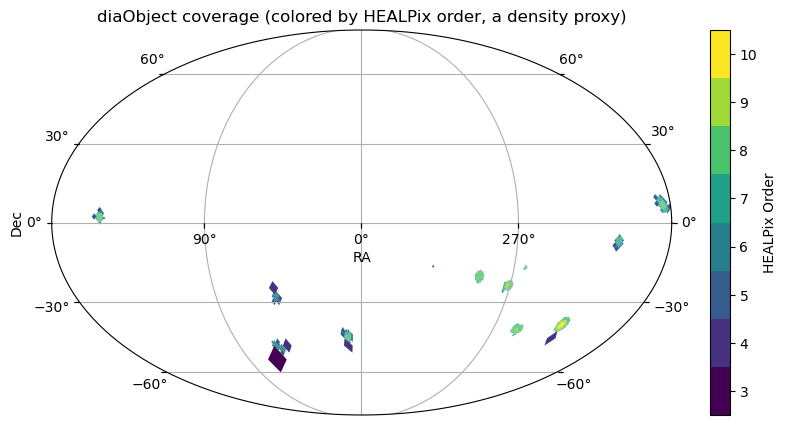

In [23]:
fig, ax = dia_object_hq.plot_pixels(
    plot_title="diaObject coverage (colored by HEALPix order, a density proxy)"
)

In [36]:
hq_stats = dia_object_hq.per_partition_statistics()

In [37]:
hq_stats

,dec: min_value,dec: max_value,dec: null_count,dec: row_count,dec: disk_bytes,dec: memory_bytes,diaObjectId: min_value,diaObjectId: max_value,diaObjectId: null_count,diaObjectId: row_count,diaObjectId: disk_bytes,diaObjectId: memory_bytes,nDiaSources: min_value,nDiaSources: max_value,nDiaSources: null_count,nDiaSources: row_count,nDiaSources: disk_bytes,nDiaSources: memory_bytes,ra: min_value,ra: max_value,ra: null_count,ra: row_count,ra: disk_bytes,ra: memory_bytes,tract: min_value,tract: max_value,tract: null_count,tract: row_count,tract: disk_bytes,tract: memory_bytes,diaObjectForcedSource.band: min_value,diaObjectForcedSource.band: max_value,diaObjectForcedSource.band: null_count,diaObjectForcedSource.band: row_count,diaObjectForcedSource.band: disk_bytes,diaObjectForcedSource.band: memory_bytes,diaObjectForcedSource.coord_dec: min_value,diaObjectForcedSource.coord_dec: max_value,diaObjectForcedSource.coord_dec: null_count,diaObjectForcedSource.coord_dec: row_count,diaObjectForcedSource.coord_dec: disk_bytes,diaObjectForcedSource.coord_dec: memory_bytes,diaObjectForcedSource.coord_ra: min_value,diaObjectForcedSource.coord_ra: max_value,diaObjectForcedSource.coord_ra: null_count,diaObjectForcedSource.coord_ra: row_count,diaObjectForcedSource.coord_ra: disk_bytes,diaObjectForcedSource.coord_ra: memory_bytes,diaObjectForcedSource.diff_PixelFlags_nodataCenter: min_value,diaObjectForcedSource.diff_PixelFlags_nodataCenter: max_value,diaObjectForcedSource.diff_PixelFlags_nodataCenter: null_count,diaObjectForcedSource.diff_PixelFlags_nodataCenter: row_count,diaObjectForcedSource.diff_PixelFlags_nodataCenter: disk_bytes,diaObjectForcedSource.diff_PixelFlags_nodataCenter: memory_bytes,diaObjectForcedSource.invalidPsfFlag: min_value,diaObjectForcedSource.invalidPsfFlag: max_value,diaObjectForcedSource.invalidPsfFlag: null_count,diaObjectForcedSource.invalidPsfFlag: row_count,diaObjectForcedSource.invalidPsfFlag: disk_bytes,diaObjectForcedSource.invalidPsfFlag: memory_bytes,diaObjectForcedSource.midpointMjdTai: min_value,diaObjectForcedSource.midpointMjdTai: max_value,diaObjectForcedSource.midpointMjdTai: null_count,diaObjectForcedSource.midpointMjdTai: row_count,diaObjectForcedSource.midpointMjdTai: disk_bytes,diaObjectForcedSource.midpointMjdTai: memory_bytes,diaObjectForcedSource.pixelFlags_bad: min_value,diaObjectForcedSource.pixelFlags_bad: max_value,diaObjectForcedSource.pixelFlags_bad: null_count,diaObjectForcedSource.pixelFlags_bad: row_count,diaObjectForcedSource.pixelFlags_bad: disk_bytes,diaObjectForcedSource.pixelFlags_bad: memory_bytes,diaObjectForcedSource.pixelFlags_cr: min_value,diaObjectForcedSource.pixelFlags_cr: max_value,diaObjectForcedSource.pixelFlags_cr: null_count,diaObjectForcedSource.pixelFlags_cr: row_count,diaObjectForcedSource.pixelFlags_cr: disk_bytes,diaObjectForcedSource.pixelFlags_cr: memory_bytes,diaObjectForcedSource.pixelFlags_crCenter: min_value,diaObjectForcedSource.pixelFlags_crCenter: max_value,diaObjectForcedSource.pixelFlags_crCenter: null_count,diaObjectForcedSource.pixelFlags_crCenter: row_count,diaObjectForcedSource.pixelFlags_crCenter: disk_bytes,diaObjectForcedSource.pixelFlags_crCenter: memory_bytes,diaObjectForcedSource.pixelFlags_edge: min_value,diaObjectForcedSource.pixelFlags_edge: max_value,diaObjectForcedSource.pixelFlags_edge: null_count,diaObjectForcedSource.pixelFlags_edge: row_count,diaObjectForcedSource.pixelFlags_edge: disk_bytes,diaObjectForcedSource.pixelFlags_edge: memory_bytes,diaObjectForcedSource.pixelFlags_interpolated: min_value,diaObjectForcedSource.pixelFlags_interpolated: max_value,diaObjectForcedSource.pixelFlags_interpolated: null_count,diaObjectForcedSource.pixelFlags_interpolated: row_count,diaObjectForcedSource.pixelFlags_interpolated: disk_bytes,diaObjectForcedSource.pixelFlags_interpolated: memory_bytes,diaObjectForcedSource.pixelFlags_interpolatedCenter: min_value,diaObjectForcedSource.pixelFlags_interpolatedCenter: max_value,diaObjectForcedSource.pixelFlag

In [40]:
hq_stats.columns

Index(['dec: min_value', 'dec: max_value', 'dec: null_count', 'dec: row_count',
       'dec: disk_bytes', 'dec: memory_bytes', 'diaObjectId: min_value',
       'diaObjectId: max_value', 'diaObjectId: null_count',
       'diaObjectId: row_count',
       ...
       'diaSource.y: null_count', 'diaSource.y: row_count',
       'diaSource.y: disk_bytes', 'diaSource.y: memory_bytes',
       'diaSource.yErr: min_value', 'diaSource.yErr: max_value',
       'diaSource.yErr: null_count', 'diaSource.yErr: row_count',
       'diaSource.yErr: disk_bytes', 'diaSource.yErr: memory_bytes'],
      dtype='object', length=486)

<Axes: >

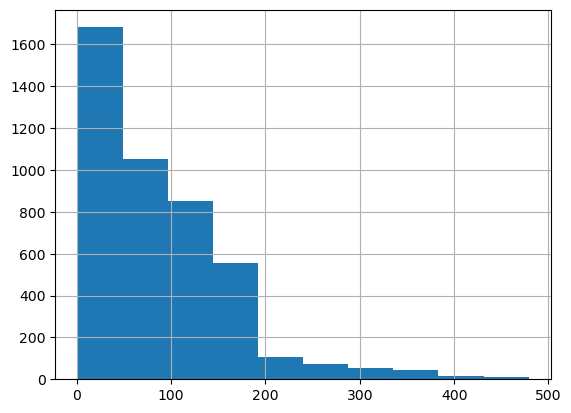

In [42]:
hq_stats['diaObjectId: row_count'].hist()

In [43]:
hq_stats['diaObjectId: row_count'].sum()

np.int64(398916)

## 6. Read the subset back, convert to pandas/numpy

`reopened` (opened above to draw the coverage plot) exercises the same `datapaths` + `lsdb`
path everyone else will use to read this subset. `.compute()` turns the (small, one partition
per field) lazy `lsdb.Catalog` into an in-memory `nested_pandas.NestedFrame` — a pandas
`DataFrame` subclass where the nested light-curve columns hold one array/list per row.
Dropping those nested columns gives an ordinary flat `pandas.DataFrame`; pulling a single
column out gives a plain `numpy` array as usual.

In [29]:
nested_df = dia_object_hq.partitions[200]
nested_df = nested_df.compute()
print(type(nested_df), nested_df.shape)

flat_df = nested_df.drop(columns=["diaSource", "diaObjectForcedSource"])
print(type(flat_df), flat_df.shape)
flat_df.head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

<class 'nested_pandas.nestedframe.core.NestedFrame'> (42, 7)
<class 'nested_pandas.nestedframe.core.NestedFrame'> (42, 5)


,dec,diaObjectId,nDiaSources,ra,tract
_healpix_29,,,,,
1918120089563200537,1.970019,788012974240432238,219,149.589554,9813
1918120134265825385,1.97887,788012974240432143,190,149.609931,9813
1918120169899973722,1.96894,788013042959908899,129,149.573488,9813
1918120360883513410,2.004394,788012974240432130,268,149.627216,9813
1918120552114538001,2.033824,788012974240432162,107,149.617547,9813


In [30]:
n_dia_sources = flat_df["nDiaSources"].to_numpy()
print(type(n_dia_sources), n_dia_sources.dtype, n_dia_sources.shape)
print("min/median/max:", n_dia_sources.min(), np.median(n_dia_sources), n_dia_sources.max())

<class 'numpy.ndarray'> int64 (42,)
min/median/max: 101 201.0 304


## 7. Building a long-format light-curve table via `explode`

Each row of `nested_df` is one object with a nested `diaSource` column holding its whole
light curve as arrays. `nested_pandas`'s `.explode(column)` turns that into a long-format
table with one row per epoch — the shape most people expect for plotting or period-finding.

Two things to watch for:
- `diaSource` itself has `ra`/`dec` columns that collide with the object-level `ra`/`dec`,
  so select only `diaObjectId` + the nested column (plus whatever flat columns you actually
  need) before exploding.
- `explode` works on an already-`compute()`d, pandas-backed frame — it's a `nested_pandas`
  method, not something you call on the lazy `lsdb.Catalog` directly.

In [31]:
example_ids = nested_df["diaObjectId"].iloc[:3]
lc_table = nested_df.loc[
    nested_df["diaObjectId"].isin(example_ids), ["diaObjectId", "diaSource"]
].explode("diaSource")

print(lc_table.shape)
lc_table[["diaObjectId", "band", "midpointMjdTai", "psfMag", "psfMagErr"]].head(10)

(538, 51)


,diaObjectId,band,midpointMjdTai,psfMag,psfMagErr
_healpix_29,,,,,
1918120089563200537,788012974240432238,z,60811.060322,20.944534,0.182486
1918120089563200537,788012974240432238,z,60811.060798,20.665815,0.109363
1918120089563200537,788012974240432238,z,60811.061274,20.135344,0.058336
1918120089563200537,788012974240432238,z,60811.061747,20.51989,0.15605
1918120089563200537,788012974240432238,z,60811.062222,20.345747,0.078273
1918120089563200537,788012974240432238,z,60811.062697,20.432411,0.075792
1918120089563200537,788012974240432238,z,60811.063172,20.469576,0.077532
1918120089563200537,788012974240432238,z,60811.06365,20.378437,0.084892
1918120089563200537,788012974240432238,z,60811.064124,19.884687,0.052737
